# Viral Product Intelligence — Review 1 Analysis

**Group 13** | Business Analytics Capstone Project

**Objective:** Early Detection and Prediction of Consumer Demand Surges Using Multi-Source Signals

---

## 1. Problem Statement (SCRUM-12)

### The Problem
In today's fast-moving consumer electronics market, certain products experience sudden **viral demand surges** — driven by social media buzz, influencer reviews, and organic consumer interest. By the time businesses recognize these surges through traditional sales data, it is **too late** for:
- Inventory restocking
- Marketing campaign alignment
- Supply chain preparation
- Competitive pricing decisions

### The Opportunity
Early consumer signals — such as **search interest growth**, **YouTube review activity**, **sentiment trends**, and **social engagement patterns** — appear **days or weeks before** a visible demand surge. If detected early, these signals can provide actionable intelligence.

### Our Approach
We collect multi-source consumer signal data (Google Trends, YouTube Data API) for **60 smartphones** in the Indian market, categorized as:
- 🔴 **RISING** — newly launched or upcoming products (24 products)
- 🟢 **STABLE** — current, steady-interest products (24 products)
- 🔵 **DECLINING** — superseded or older models (12 products)

We analyze how these signals change over time and build predictive models to identify **emerging viral products** before their demand peaks.

### Business Value
| Stakeholder | Benefit |
|------------|--------|
| Retailers | Early inventory planning |
| Marketers | Optimal campaign timing |
| Manufacturers | Demand-driven production |
| Analysts | Data-driven trend forecasting |

---

## 2. Setup & Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Style settings
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Paths (relative to notebooks/)
DATA_DIR = os.path.join('..', 'data')
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed')
YT_DIR = os.path.join(DATA_DIR, 'youtube')

print('Setup complete.')

Setup complete.


---

## 3. Product Registry — Exploratory Data Analysis (SCRUM-5)

### 3.1 Load and Inspect the Product Registry

In [2]:
# Load the product registry
products = pd.read_csv(os.path.join(DATA_DIR, 'products.csv'))

print(f'Total products: {len(products)}')
print(f'Columns: {list(products.columns)}')
print()
products.head(10)

Total products: 60
Columns: ['product_id', 'product_name', 'brand', 'category', 'trends_query', 'youtube_query', 'launch_period', 'product_type', 'notes']



,product_id,product_name,brand,category,trends_query,youtube_query,launch_period,product_type,notes
0,P001,Apple iPhone 18 Pro,Apple,Smartphones,iphone 18 pro,iphone 18 pro review,2026-09,RISING,Trends query also matches iphone 18 pro max se...
1,P002,Apple iPhone 18 Pro Max,Apple,Smartphones,iphone 18 pro max,iphone 18 pro max review,2026-09,RISING,India sale from 2026-09-18
2,P003,Apple iPhone Duo,Apple,Smartphones,iphone duo,iphone duo review,2026-09,RISING,Apple foldable; name and India pricing confirm...
3,P004,Samsung Galaxy Z Fold 8,Samsung,Smartphones,galaxy z fold 8,galaxy z fold 8 review,2026-07,RISING,Trends query also matches galaxy z fold 8 ultr...
4,P005,Samsung Galaxy Z Fold 8 Ultra,Samsung,Smartphones,galaxy z fold 8 ultra,galaxy z fold 8 ultra review,2026-07,RISING,verify Trends volume; may be too low to separa...
5,P006,Samsung Galaxy Z Flip 8,Samsung,Smartphones,galaxy z flip 8,galaxy z flip 8 review,2026-07,RISING,India general sale from 2026-08-08
6,P007,Samsung Galaxy S26 FE,Samsung,Smartphones,galaxy s26 fe,galaxy s26 fe review,2026-09,RISING,India launch 2026-09-14
7,P008,Google Pixel 11,Google,Smartphones,pixel 11,pixel 11 review,2026-08,RISING,Trends query also matches Pixel 11 Pro / Pro X...
8,P009,Google Pixel 11 Pro,Google,Smartphones,pixel 11 pro,pixel 11 pro review,2026-08,RISING,Trends query also matches Pixel 11 Pro XL and ...
9,P010,Google Pixel 11 Pro XL,Google,Smartphones,pixel 11 pro xl,pixel 11 pro xl review,2026-08,RISING,verify Trends volume


In [3]:
# Basic stats
print('=== Product Registry Summary ===')
print(f'Total products tracked: {len(products)}')
print(f'Unique brands: {products["brand"].nunique()}')
print(f'Category: {products["category"].unique()[0]}')
print()
print('--- Product Type Distribution ---')
print(products['product_type'].value_counts())
print()
print('--- Brand Distribution ---')
print(products['brand'].value_counts())

=== Product Registry Summary ===
Total products tracked: 60
Unique brands: 13
Category: Smartphones

--- Product Type Distribution ---
product_type
RISING       24
STABLE       24
DECLINING    12
Name: count, dtype: int64

--- Brand Distribution ---
brand
Samsung     13
Apple        9
Google       6
OnePlus      5
Redmi        5
Vivo         5
Oppo         4
Poco         3
Nothing      3
iQOO         2
Motorola     2
Realme       2
Infinix      1
Name: count, dtype: int64


### 3.2 Product Type Distribution

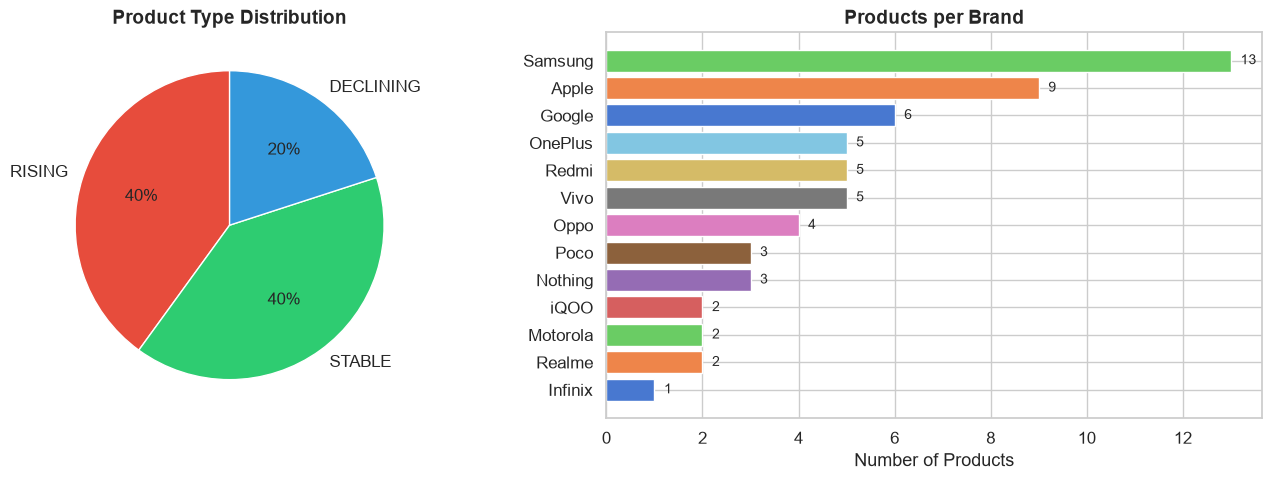

Saved: docs/product_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart - Product Type Distribution
type_counts = products['product_type'].value_counts()
colors_type = {'RISING': '#e74c3c', 'STABLE': '#2ecc71', 'DECLINING': '#3498db'}
type_colors = [colors_type.get(t, '#95a5a6') for t in type_counts.index]

axes[0].pie(type_counts.values, labels=type_counts.index, autopct='%1.0f%%',
            colors=type_colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Product Type Distribution', fontsize=14, fontweight='bold')

# Bar chart - Brand Distribution
brand_counts = products['brand'].value_counts()
bars = axes[1].barh(brand_counts.index[::-1], brand_counts.values[::-1],
                    color=sns.color_palette('muted', len(brand_counts)))
axes[1].set_xlabel('Number of Products')
axes[1].set_title('Products per Brand', fontsize=14, fontweight='bold')
for bar in bars:
    width = bar.get_width()
    axes[1].text(width + 0.2, bar.get_y() + bar.get_height()/2, f'{int(width)}',
                ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../docs/product_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: docs/product_distribution.png')

### 3.3 Brand x Product Type Heatmap

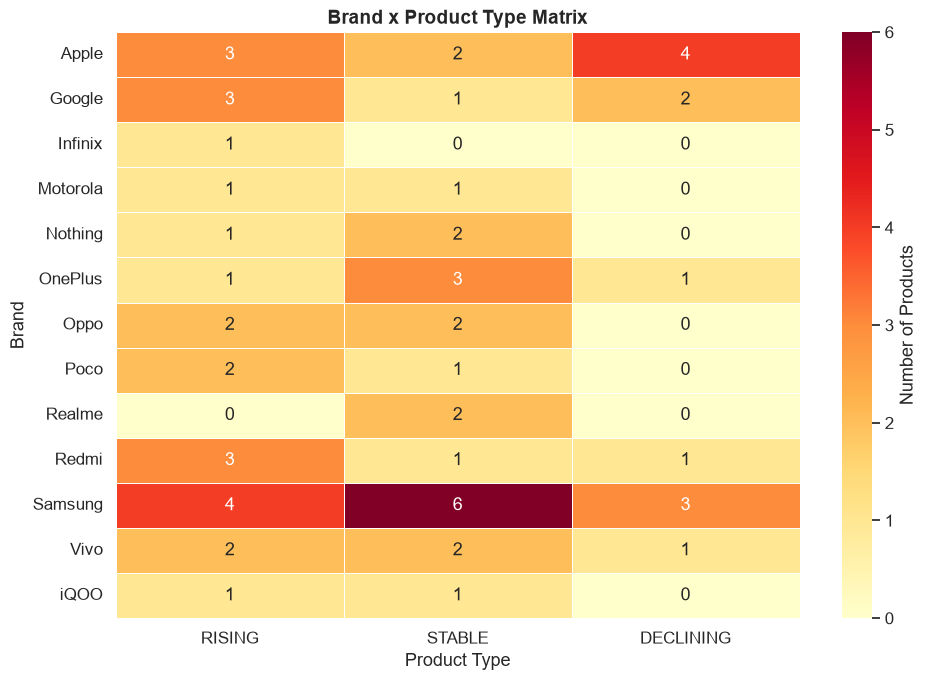

In [5]:
# Brand vs Product Type crosstab
brand_type = pd.crosstab(products['brand'], products['product_type'])
for col in ['RISING', 'STABLE', 'DECLINING']:
    if col not in brand_type.columns:
        brand_type[col] = 0
brand_type = brand_type[['RISING', 'STABLE', 'DECLINING']]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(brand_type, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Number of Products'}, ax=ax)
ax.set_title('Brand x Product Type Matrix', fontsize=14, fontweight='bold')
ax.set_ylabel('Brand')
ax.set_xlabel('Product Type')
plt.tight_layout()
plt.savefig('../docs/brand_type_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.4 Launch Timeline

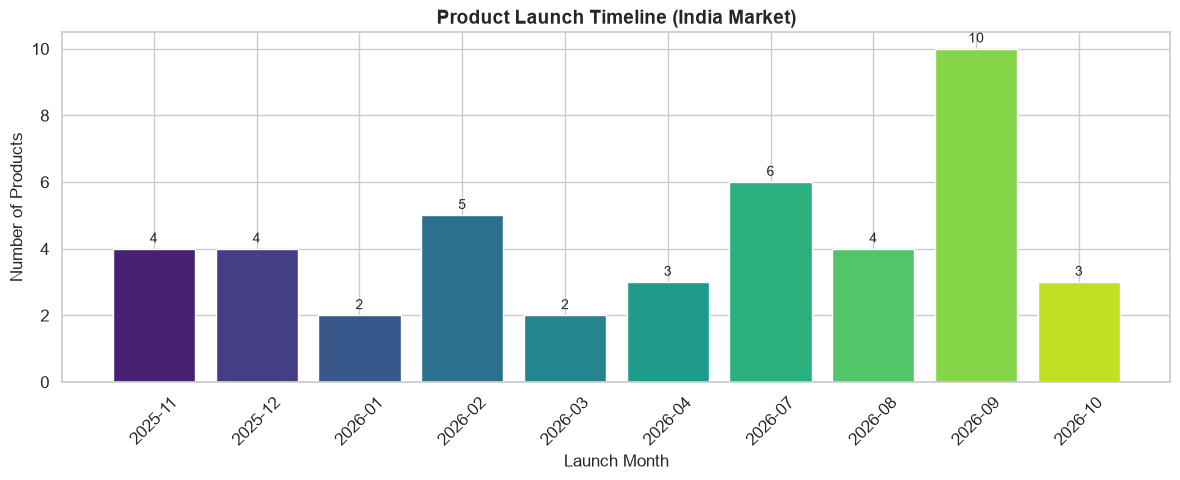

In [6]:
# Launch period distribution (exclude 'established' and 'unverified')
launch_data = products[~products['launch_period'].isin(['established', 'unverified'])].copy()
launch_counts = launch_data['launch_period'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(launch_counts.index, launch_counts.values,
              color=sns.color_palette('viridis', len(launch_counts)))
ax.set_xlabel('Launch Month', fontsize=12)
ax.set_ylabel('Number of Products', fontsize=12)
ax.set_title('Product Launch Timeline (India Market)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.1, f'{int(height)}',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('../docs/launch_timeline.png', bbox_inches='tight', dpi=150)
plt.show()

---

## 4. Data Sources Documentation (SCRUM-5)

### 4.1 Source Log

In [7]:
source_log = pd.read_csv(os.path.join(DATA_DIR, 'source_log.csv'))
print(f'Data sources documented: {len(source_log)}')
print()
for i, row in source_log.iterrows():
    print(f'Source {i+1}: {row["source"]}')
    print(f'  Access: {str(row["access_method"])[:100]}...')
    print(f'  Granularity: {row["granularity"]}')
    print(f'  Added: {row["added_date"]}')
    print()

Data sources documented: 4

Source 1: YouTube Data API v3
  Access: Official REST API with an API key (src/collect_youtube.py); search.list then videos.list then commen...
  Granularity: daily snapshot per product (counts are cumulative at collection time)
  Added: 2026-10-03

Source 2: Google Trends
  Access: Manual CSV export from trends.google.com (Interest over time), saved untouched to raw/trends/ and pa...
  Granularity: weekly for a 12-month window (daily for windows of 90 days or less)
  Added: 2026-10-03

Source 3: Google Trends
  Access: Manual CSV export from trends.google.com (Interest over time) with a custom time range, saved untouc...
  Granularity: daily; window changed on 2026-10-03 from 12 months weekly to a 269-day custom range (about 9 months), identical for every product; supersedes the earlier Google Trends row
  Added: 2026-10-03

Source 4: YouTube Data API v3
  Access: Official REST API with an API key (src/collect_youtube.py). Main pass: search.list (order=rele

### 4.2 Collection Log

In [8]:
collection_log = pd.read_csv(os.path.join(DATA_DIR, 'collection_log.csv'))
print(f'Total collection runs: {len(collection_log)}')
print(f'All runs successful: {(collection_log["status"].isin(["success", "smoke_test_ok"])).all()}')
print()
print('--- Records Collected by Source ---')
summary = collection_log.groupby('source').agg(
    runs=('status', 'count'),
    total_records=('records_collected', 'sum'),
    total_quota_units=('quota_units', 'sum')
).reset_index()
print(summary.to_string(index=False))
print()
print('--- Pilot Products ---')
collected = collection_log[collection_log['status'] == 'success']['product_id'].unique()
print(f'Products with YouTube data: {len(collected)}')
print(f'IDs: {sorted(collected)}')

Total collection runs: 23
All runs successful: True

--- Records Collected by Source ---
        source  runs  total_records  total_quota_units
       youtube    13           6244                 85
youtube_recent    10            397                 10

--- Pilot Products ---
Products with YouTube data: 10
IDs: ['P003', 'P006', 'P016', 'P018', 'P035', 'P043', 'P044', 'P046', 'P057', 'P059']


---

## 5. YouTube Data — Before vs After Cleaning (SCRUM-17)

### 5.1 Load the Cleaning Report

In [9]:
cleaning = pd.read_csv(os.path.join(PROCESSED_DIR, 'cleaning_report_youtube.csv'))
print(f'Cleaning report entries: {len(cleaning)}')
print(f'Tables cleaned: {cleaning["table"].unique().tolist()}')
print()
cleaning.head(15)

Cleaning report entries: 76
Tables cleaned: ['videos', 'comments', 'product_daily', 'recent_window']



,table,step,column,rows_before,rows_after,rows_dropped,missing_before,missing_after,detail
0,videos,load,NaN,600.0,600.0,0.0,NaN,NaN,rows read from the input file
1,videos,normalize_column_names,NaN,600.0,600.0,0.0,NaN,NaN,already snake_case
2,videos,normalize_product_id,NaN,600.0,600.0,0.0,NaN,NaN,dropped: product_id not like P001
3,videos,standardize_dates,NaN,600.0,600.0,0.0,NaN,NaN,snapshot_date -> YYYY-MM-DD (unparseable rows ...
4,videos,select_active_query,NaN,600.0,500.0,100.0,NaN,NaN,excluded rows not collected with the active re...
5,videos,drop_exact_duplicates,NaN,500.0,500.0,0.0,NaN,NaN,identical rows; keep first seen
6,videos,drop_key_duplicates,NaN,500.0,500.0,0.0,NaN,NaN,"key (snapshot_date, product_id, query_version,..."
7,videos,types_zero_vs_missing,NaN,500.0,500.0,0.0,NaN,NaN,"counts -> integers; empty, non-numeric or nega..."
8,videos,clean_title,NaN,500.0,500.0,0.0,NaN,NaN,"36 value(s) changed: HTML entities decoded, ta..."
9,videos,output,NaN,600.0,500.0,100.0,NaN,NaN,outliers kept; rows sorted by key


### 5.2 Before vs After Summary

In [10]:
tables = cleaning['table'].unique()
before_after = []
for table in tables:
    td = cleaning[cleaning['table'] == table]
    load = td[td['step'] == 'load']
    out  = td[td['step'] == 'output']
    if not load.empty and not out.empty:
        b = int(load['rows_before'].iloc[0])
        a = int(out['rows_after'].iloc[0])
        d = int(out['rows_dropped'].iloc[0])
        before_after.append({'Table': table, 'Before': b, 'After': a,
                             'Dropped': d, 'Drop%': round(d/b*100, 1) if b else 0})

ba_df = pd.DataFrame(before_after)
print('=== Before vs After Cleaning ===')
print(ba_df.to_string(index=False))

=== Before vs After Cleaning ===
        Table  Before  After  Dropped  Drop%
       videos     600    500      100   16.7
     comments    5639   4639     1000   17.7
product_daily      12     10        2   16.7
recent_window      10     10        0    0.0


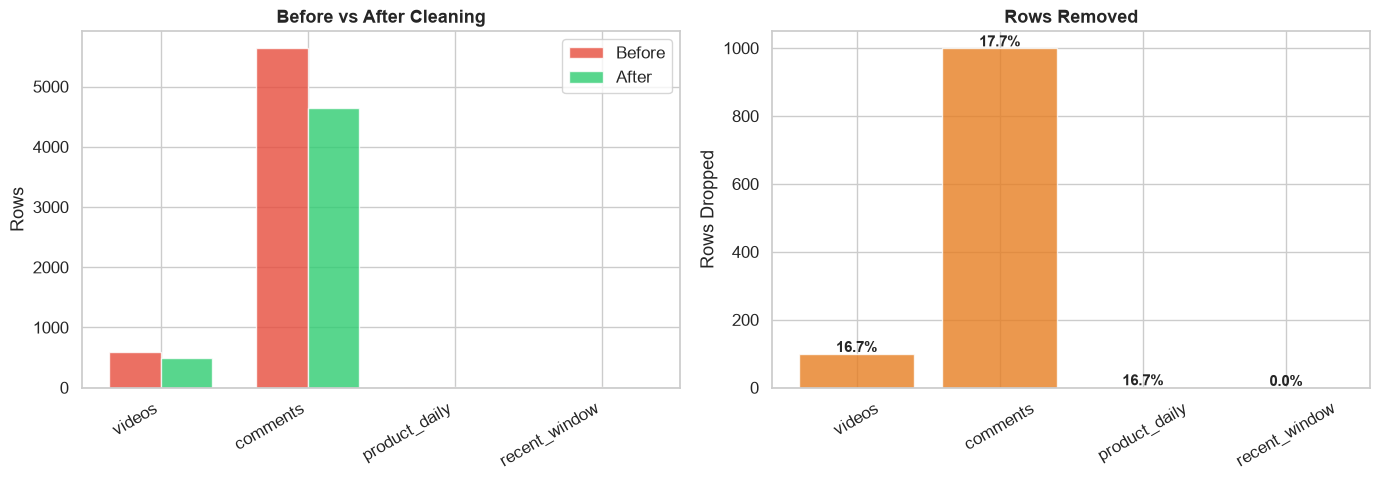

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(ba_df))
w = 0.35
axes[0].bar([i - w/2 for i in x], ba_df['Before'], w, label='Before', color='#e74c3c', alpha=0.8)
axes[0].bar([i + w/2 for i in x], ba_df['After'],  w, label='After',  color='#2ecc71', alpha=0.8)
axes[0].set_ylabel('Rows')
axes[0].set_title('Before vs After Cleaning', fontsize=13, fontweight='bold')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(ba_df['Table'], rotation=30, ha='right')
axes[0].legend()

bars = axes[1].bar(ba_df['Table'], ba_df['Dropped'], color='#e67e22', alpha=0.8)
axes[1].set_ylabel('Rows Dropped')
axes[1].set_title('Rows Removed', fontsize=13, fontweight='bold')
for bar, pct in zip(bars, ba_df['Drop%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{pct}%', ha='center', fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../docs/before_after_cleaning.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.3 Impactful Cleaning Steps

In [12]:
impactful = cleaning[
    (cleaning['rows_dropped'].fillna(0).astype(float) > 0) |
    (cleaning['detail'].str.contains('changed|excluded|flagged', case=False, na=False))
].copy()

print('=== Cleaning Steps That Modified Data ===')
for _, row in impactful.iterrows():
    d = row['rows_dropped']
    ds = f', dropped {int(float(d))}' if pd.notna(d) and float(d) > 0 else ''
    print(f'[{row["table"]}] {row["step"]}{ds}')
    print(f'  -> {row["detail"]}')
    print()

=== Cleaning Steps That Modified Data ===
[videos] select_active_query, dropped 100
  -> excluded rows not collected with the active registry's query: P044 v2: 50 (active is v1); P057 v1: 50 (active is v2)

[videos] clean_title
  -> 36 value(s) changed: HTML entities decoded, tags stripped, whitespace collapsed

[videos] output, dropped 100
  -> outliers kept; rows sorted by key

[comments] select_active_query, dropped 1000
  -> excluded rows not collected with the active registry's query: P044 v2: 500 (active is v1); P057 v1: 500 (active is v2)

[comments] clean_text
  -> 504 value(s) changed: HTML entities decoded, tags stripped, whitespace collapsed

[comments] flag_language
  -> flagged, not dropped: is_emoji_only=54, likely_non_english=123

[comments] output, dropped 1000
  -> outliers kept; rows sorted by key

[product_daily] select_active_query, dropped 2
  -> excluded rows not collected with the active registry's query: P044 v2: 1 (active is v1); P057 v1: 1 (active is v2)

[pro

### 5.4 Missing Values

In [13]:
missing = cleaning[cleaning['step'] == 'missing_values'].copy()
missing = missing[missing['missing_before'].fillna(0).astype(float) > 0]
if len(missing) > 0:
    print('=== Columns with Missing Values ===')
    for _, row in missing.iterrows():
        print(f'[{row["table"]}] {row["column"]}: '
              f'{int(float(row["missing_before"]))} before -> '
              f'{int(float(row["missing_after"]))} after')
else:
    print('No columns had missing values.')

=== Columns with Missing Values ===
[videos] like_count: 16 before -> 15 after


---

## 6. YouTube Pilot Data — Exploratory Analysis

### 6.1 Cleaned Product Daily Metrics

In [14]:
yt_daily = pd.read_csv(os.path.join(PROCESSED_DIR, 'youtube_product_daily_clean.csv'))
yt_merged = yt_daily.merge(
    products[['product_id', 'product_name', 'brand', 'product_type']],
    on='product_id', how='left'
)
print(f'Cleaned YouTube daily records: {len(yt_merged)}')
print(f'Products with data: {yt_merged["product_id"].nunique()}')
print()
yt_merged[['product_id', 'product_name', 'brand', 'product_type',
           'views_on_target_total', 'comments_on_target_total', 'on_target_share']]

Cleaned YouTube daily records: 10
Products with data: 10



,product_id,product_name,brand,product_type,views_on_target_total,comments_on_target_total,on_target_share
0,P003,Apple iPhone Duo,Apple,RISING,125250483,95178,0.92
1,P006,Samsung Galaxy Z Flip 8,Samsung,RISING,5511804,4869,0.92
2,P016,Poco X8 Power,Poco,RISING,4038524,4136,0.80
3,P018,Vivo T5 5G,Vivo,RISING,7765027,3967,0.86
4,P035,OnePlus 15R,OnePlus,STABLE,42855829,16216,0.92
5,P043,Realme GT 8 Pro,Realme,STABLE,12261596,9052,0.96
6,P044,Motorola Edge 70,Motorola,STABLE,21840155,14948,0.56
7,P046,Oppo Reno 15,Oppo,STABLE,7593334,10312,0.94
8,P057,Google Pixel 9,Google,DECLINING,20077104,12298,0.64
9,P059,Redmi Note 14 Pro Plus,Redmi,DECLINING,20913146,32952,0.96


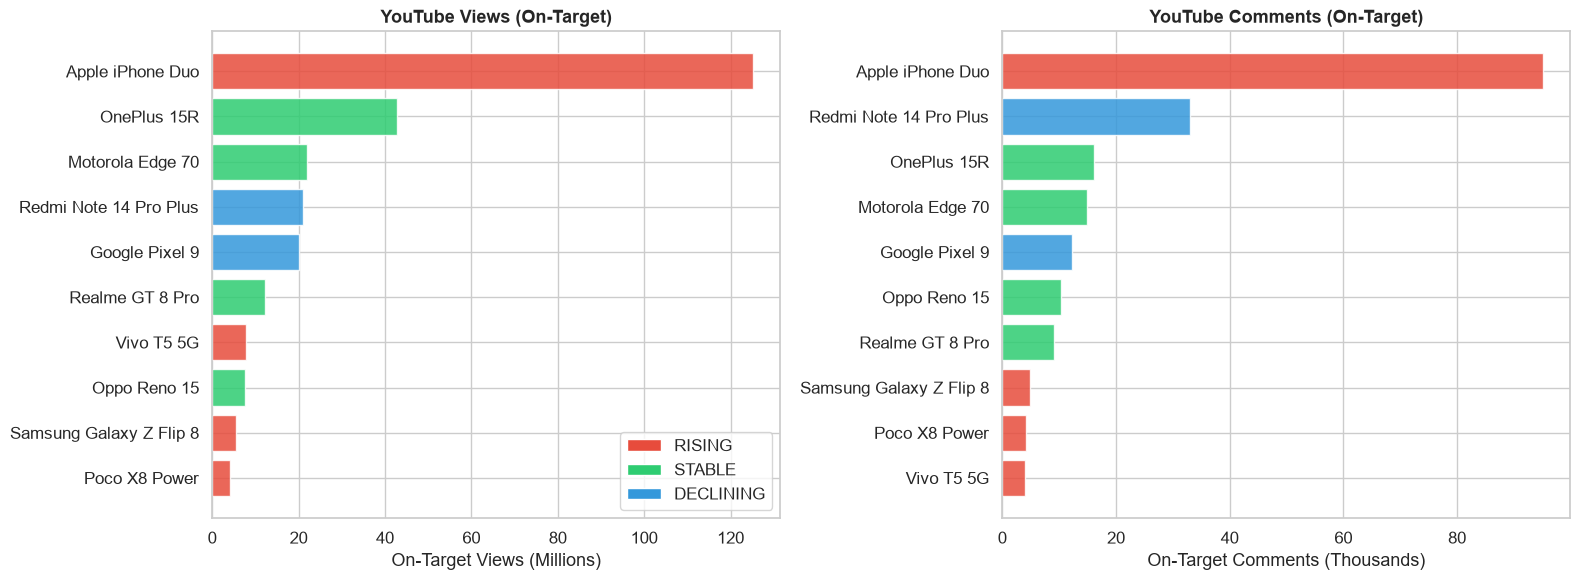

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'RISING': '#e74c3c', 'STABLE': '#2ecc71', 'DECLINING': '#3498db'}

# Views
s = yt_merged.sort_values('views_on_target_total', ascending=True)
axes[0].barh(s['product_name'], s['views_on_target_total'] / 1e6,
             color=[colors.get(t, '#95a5a6') for t in s['product_type']], alpha=0.85)
axes[0].set_xlabel('On-Target Views (Millions)')
axes[0].set_title('YouTube Views (On-Target)', fontsize=13, fontweight='bold')

# Comments
s2 = yt_merged.sort_values('comments_on_target_total', ascending=True)
axes[1].barh(s2['product_name'], s2['comments_on_target_total'] / 1e3,
             color=[colors.get(t, '#95a5a6') for t in s2['product_type']], alpha=0.85)
axes[1].set_xlabel('On-Target Comments (Thousands)')
axes[1].set_title('YouTube Comments (On-Target)', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(facecolor=c, label=l) for l, c in colors.items()], loc='lower right')
plt.tight_layout()
plt.savefig('../docs/youtube_views_comments.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.2 On-Target Share Analysis

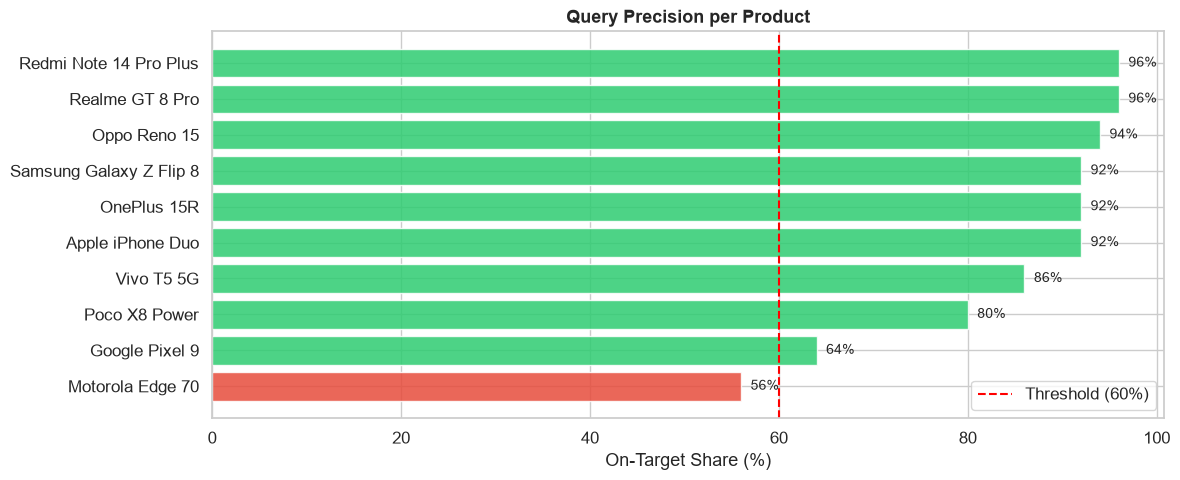

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
s = yt_merged.sort_values('on_target_share', ascending=True)
bc = ['#e74c3c' if x else '#2ecc71' for x in s['low_on_target_share']]
ax.barh(s['product_name'], s['on_target_share'] * 100, color=bc, alpha=0.85)
ax.axvline(x=60, color='red', linestyle='--', linewidth=1.5, label='Threshold (60%)')
ax.set_xlabel('On-Target Share (%)')
ax.set_title('Query Precision per Product', fontsize=13, fontweight='bold')
ax.legend()
for i, (_, row) in enumerate(s.iterrows()):
    ax.text(row['on_target_share']*100 + 1, i, f"{row['on_target_share']*100:.0f}%",
            va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../docs/on_target_share.png', bbox_inches='tight', dpi=150)
plt.show()

### 6.3 Recent Upload Activity (7-Day Window)

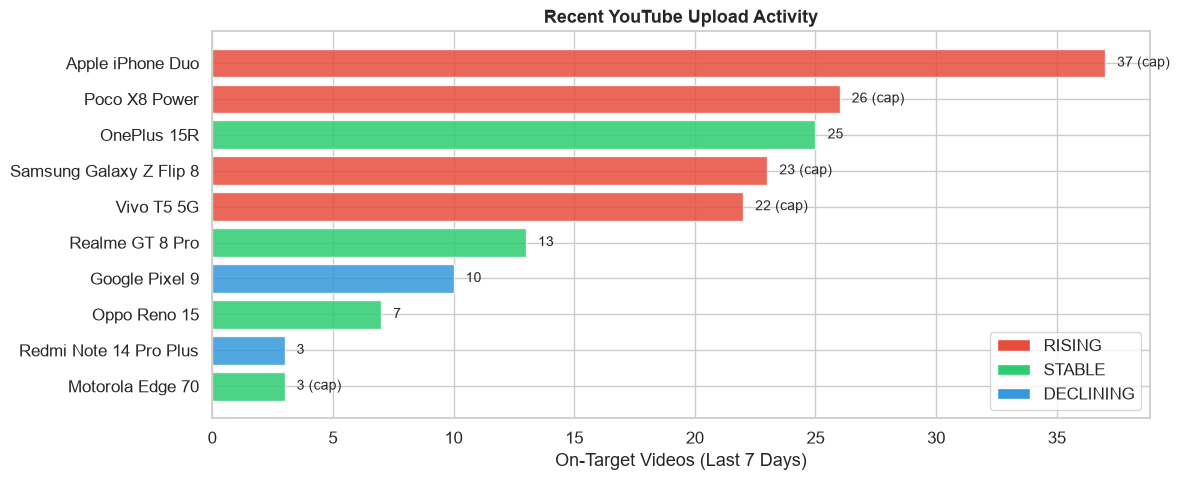

In [17]:
yt_recent = pd.read_csv(os.path.join(PROCESSED_DIR, 'youtube_recent_window_clean.csv'))
yt_rm = yt_recent.merge(
    products[['product_id', 'product_name', 'brand', 'product_type']],
    on='product_id', how='left'
)
fig, ax = plt.subplots(figsize=(12, 5))
s = yt_rm.sort_values('videos_7d_on_target', ascending=True)
ax.barh(s['product_name'], s['videos_7d_on_target'],
        color=[colors.get(t, '#95a5a6') for t in s['product_type']], alpha=0.85)
ax.set_xlabel('On-Target Videos (Last 7 Days)')
ax.set_title('Recent YouTube Upload Activity', fontsize=13, fontweight='bold')
for i, (_, row) in enumerate(s.iterrows()):
    label = f"{int(row['videos_7d_on_target'])}"
    if row.get('cap_hit', False): label += ' (cap)'
    ax.text(row['videos_7d_on_target'] + 0.5, i, label, va='center', fontsize=10)
ax.legend(handles=[Patch(facecolor=c, label=l) for l, c in colors.items()], loc='lower right')
plt.tight_layout()
plt.savefig('../docs/recent_uploads.png', bbox_inches='tight', dpi=150)
plt.show()

---

## 7. Video-Level Analysis

In [18]:
# Load raw video snapshot (Ashwin pushed this to main)
videos = pd.read_csv(os.path.join(YT_DIR, 'videos_snapshot.csv'))
videos = videos.merge(products[['product_id', 'product_name', 'brand', 'product_type']],
                      on='product_id', how='left')
print(f'Total video records: {len(videos)}')
print(f'Columns: {list(videos.columns)}')
print()

# Top 10 most viewed videos across all products
top_videos = videos.nlargest(10, 'view_count')[['product_name', 'title', 'view_count', 'like_count', 'comment_count']]
print('=== Top 10 Most Viewed Videos ===')
for i, (_, row) in enumerate(top_videos.iterrows(), 1):
    print(f'{i}. [{row["product_name"]}] {str(row["title"])[:60]}')
    print(f'   Views: {int(row["view_count"]):,} | Comments: {int(row["comment_count"]):,}')
    print()

Total video records: 600
Columns: ['snapshot_date', 'product_id', 'query_version', 'video_id', 'title', 'channel_id', 'published_at', 'view_count', 'like_count', 'comment_count', 'product_name', 'brand', 'product_type']

=== Top 10 Most Viewed Videos ===
1. [Apple iPhone Duo] iPhone 18 Pro/Duo Impressions: Mogged
   Views: 27,508,017 | Comments: 24,897

2. [OnePlus 15R] पापा के पैसे से लिया Best Gaming Phone : OnePlus 15R 🤩#short
   Views: 26,078,954 | Comments: 1,259

3. [Apple iPhone Duo] Don't Buy the New iPhone Duo! ⚠️
   Views: 18,700,095 | Comments: 12,670

4. [Apple iPhone Duo] Xiaomi made an iPhone Duo. It’s Unhinged.
   Views: 17,594,136 | Comments: 12,999

5. [Apple iPhone Duo] iPhone Duo/18 Pro Hands On - I wasn’t ready
   Views: 16,801,545 | Comments: 12,676

6. [Apple iPhone Duo] iPhone Duo Hands On!
   Views: 15,716,707 | Comments: 12,077

7. [Apple iPhone Duo] iPhone Duo: What We Missed!
   Views: 12,444,399 | Comments: 12,946

8. [Apple iPhone Duo] APPLE GAVE ME AN iPHO

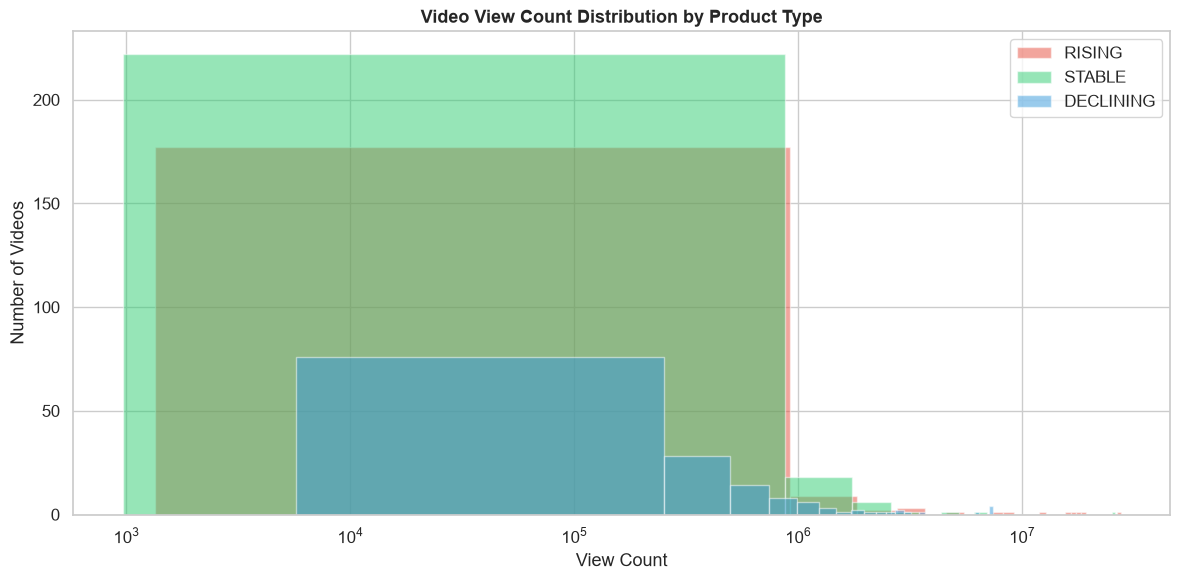

In [19]:
# View count distribution by product type
fig, ax = plt.subplots(figsize=(12, 6))
for ptype, color in colors.items():
    subset = videos[videos['product_type'] == ptype]['view_count']
    if len(subset) > 0:
        ax.hist(subset, bins=30, alpha=0.5, label=ptype, color=color)
ax.set_xlabel('View Count')
ax.set_ylabel('Number of Videos')
ax.set_title('Video View Count Distribution by Product Type', fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/view_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

---

## 8. Comment-Level Analysis Preview

Total comments: 5639



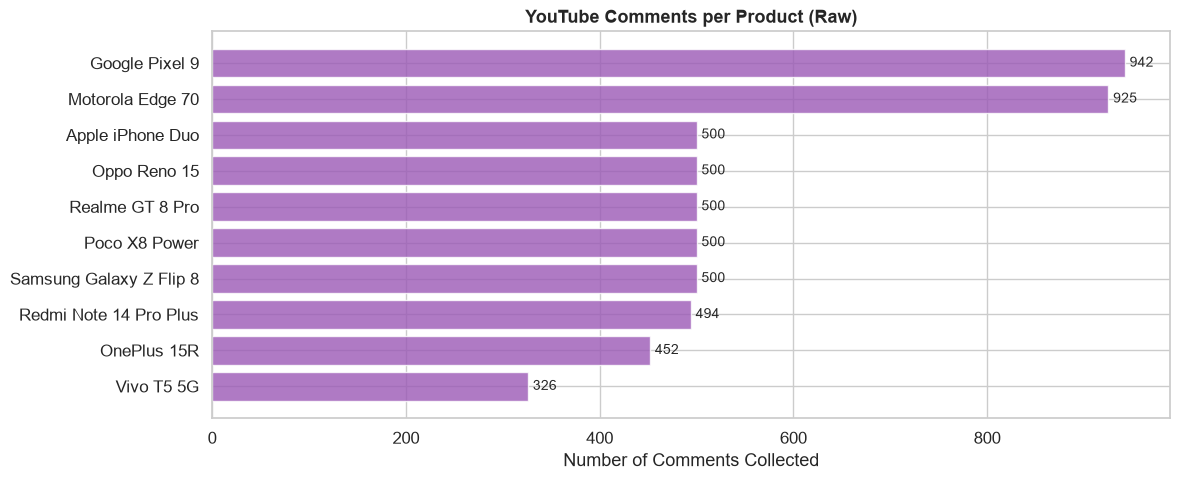

In [20]:
# Load raw comments (Ashwin pushed this to main)
comments = pd.read_csv(os.path.join(YT_DIR, 'comments_snapshot.csv'))
comments = comments.merge(products[['product_id', 'product_name', 'brand', 'product_type']],
                          on='product_id', how='left')
print(f'Total comments: {len(comments)}')
print()

# Comments per product
comment_counts = comments.groupby(['product_id', 'product_name']).size().reset_index(name='comment_count')
comment_counts = comment_counts.sort_values('comment_count', ascending=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(comment_counts['product_name'], comment_counts['comment_count'],
        color='#9b59b6', alpha=0.8)
ax.set_xlabel('Number of Comments Collected')
ax.set_title('YouTube Comments per Product (Raw)', fontsize=13, fontweight='bold')
for i, (_, row) in enumerate(comment_counts.iterrows()):
    ax.text(row['comment_count'] + 5, i, str(row['comment_count']),
            va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../docs/comments_per_product.png', bbox_inches='tight', dpi=150)
plt.show()

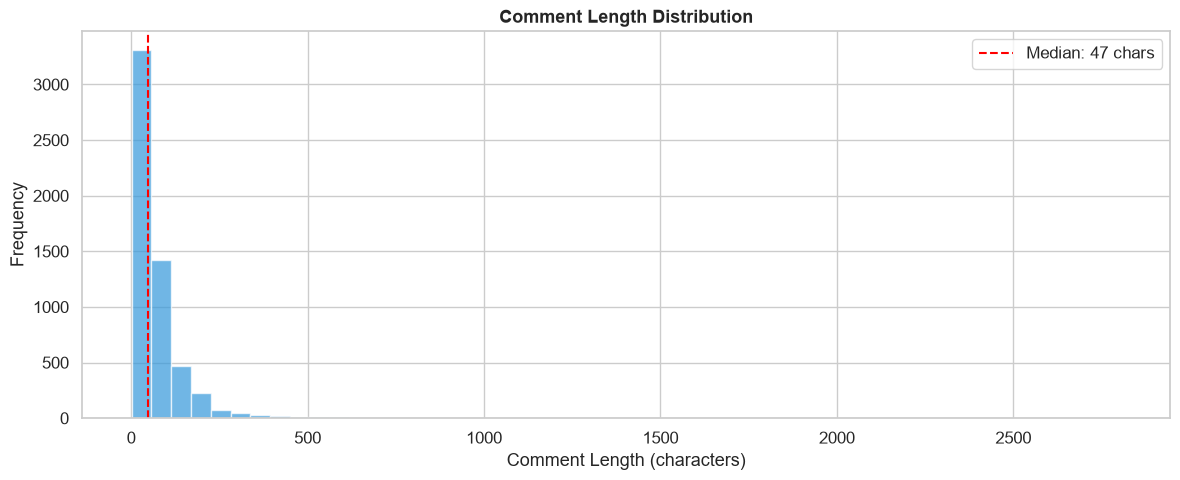

Average comment length: 71 characters
Median comment length: 47 characters
Shortest: 1 | Longest: 2805


In [21]:
# Comment length distribution
comments['text_length'] = comments['text'].str.len()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(comments['text_length'].dropna(), bins=50, color='#3498db', alpha=0.7, edgecolor='white')
ax.set_xlabel('Comment Length (characters)')
ax.set_ylabel('Frequency')
ax.set_title('Comment Length Distribution', fontsize=13, fontweight='bold')
ax.axvline(comments['text_length'].median(), color='red', linestyle='--',
           label=f'Median: {int(comments["text_length"].median())} chars')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/comment_length_dist.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Average comment length: {comments["text_length"].mean():.0f} characters')
print(f'Median comment length: {comments["text_length"].median():.0f} characters')
print(f'Shortest: {comments["text_length"].min():.0f} | Longest: {comments["text_length"].max():.0f}')

---

## 9. Before-vs-After Documentation Summary (SCRUM-17)

### Cleaning Pipeline Overview

The YouTube data cleaning pipeline (`src/clean_youtube.py`) processes four tables: **videos**, **comments**, **product_daily**, and **recent_window**.

### Key Cleaning Impact

| Table | Raw | Clean | Dropped | Rate | Reason |
|-------|-----|-------|---------|------|--------|
| videos | 600 | 500 | 100 | 16.7% | Inactive query version (P044 v2: 50, P057 v1: 50) |
| comments | 5,639 | 4,639 | 1,000 | 17.7% | Inactive query version (P044 v2: 500, P057 v1: 500) |
| product_daily | 12 | 10 | 2 | 16.7% | Inactive query version |
| recent_window | 10 | 10 | 0 | 0% | All active |

### Data Quality Notes

1. **Zero duplicates** — no exact or key duplicates in any table
2. **Query version control** — primary cleaning action; inactive versions excluded
3. **36 video titles** cleaned (HTML entities/tags)
4. **504 comment texts** cleaned (HTML entities/tags)
5. **15 videos** with hidden like counts (kept as missing, not zero)
6. **54 emoji-only** and **123 non-English** comments flagged (retained)
7. **P044** flagged: low on-target share (56%) — sibling model noise

---

## 10. Data Dictionary — Key Fields

In [22]:
data_dict = pd.read_csv(os.path.join(DATA_DIR, 'data_dictionary.csv'))
print(f'Total field definitions: {len(data_dict)}')
print(f'Columns in dictionary: {list(data_dict.columns)}')
print()
# Show first few entries as a sample
print('=== Sample Field Definitions ===')
for _, row in data_dict.head(10).iterrows():
    col_name = row.get('column', '')
    if pd.notna(col_name) and col_name:
        defn = str(row.get('definition', row.get('description', ''))).strip()
        print(f'  {col_name}: {defn[:120]}')

Total field definitions: 66
Columns in dictionary: ['file', 'column', 'type', 'definition', 'limitations']

=== Sample Field Definitions ===
  snapshot_date: Collection day in India time (Asia/Kolkata).
  product_id: Registry product id (P001..P060).
  query_version: Registry version whose youtube_query produced this row (v1, v2, ...): the oldest version with that exact query. Rows wri
  video_id: YouTube video id from search.list (type=video).
  title: videos.list snippet.title at snapshot time.
  channel_id: videos.list snippet.channelId.
  published_at: videos.list snippet.publishedAt (upload time).
  view_count: videos.list statistics.viewCount: cumulative views at snapshot time.
  like_count: videos.list statistics.likeCount: cumulative likes.
  comment_count: videos.list statistics.commentCount: cumulative comments.


---

## 11. Next Steps (Review 2)

1. **Google Trends Data** — Download CSV exports for all 60 products
2. **Aligned Dataset** — Merge Trends + YouTube via `src/build_aligned.py`
3. **Expand Collection** — Daily/weekly YouTube collection for all 60 products
4. **Sentiment Analysis** — NLP on YouTube comments (handle Hinglish)
5. **Feature Engineering** — Lag features, rolling averages, rate-of-change
6. **Predictive Modelling** — Surge detection classifiers
7. **Dashboard** — Viral Product Radar (Surging / Emerging / Stable / Declining)

In [23]:
print('=== Review 1 Analysis Complete ===')
print()
print('SCRUM-5  | Product Registry & Source Log       -- Documented')
print('SCRUM-12 | Problem Statement                   -- Drafted')
print('SCRUM-17 | Before-vs-After Data Documentation  -- Completed')

=== Review 1 Analysis Complete ===

SCRUM-5  | Product Registry & Source Log       -- Documented
SCRUM-12 | Problem Statement                   -- Drafted
SCRUM-17 | Before-vs-After Data Documentation  -- Completed
